## 12 b)

Text(0, 0.5, 'probability of the atom being in the exited state')

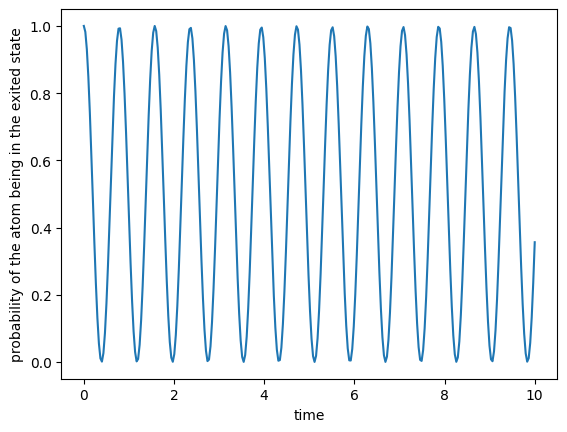

In [6]:
from qutip import basis, coherent, tensor, qeye, destroy, create, sigmap, sigmam
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt


def Hamiltonian_evolution(t,M=4,omega_eg=5, N=4, B=0.1, g=10):

    omega_list = [omega_eg + B * i for i in range(-M//2 +1,M//2 +1)]

    a_list = [destroy(N) for i in range(M)] 

    H = sum((omega_list[n] - omega_eg) * tensor(qeye(2), 
        tensor(*[a_list[i].dag() @ a_list[i] if i == n else qeye(N) for i in range(M)])) for n in range(M))
    
    H_int_1 = g/(2*np.pi*M)**(0.5)* tensor(sigmam(),sum(tensor(*[a_list[i] if i == n else qeye(N) for i in range(M)]) for n in range(M)))
    H_int_2 = g/(2*np.pi*M)**(0.5)* tensor(sigmap(),sum(tensor(*[a_list[i].dag() if i == n else qeye(N) for i in range(M)]) for n in range(M)))
    H_ges = (H+H_int_1+H_int_2).full()
    
    U = expm(-1j*H_ges*t)

    def initial_state(N=4, M=4):
        # Create the initial state
        dim_qubit=2
        psi = tensor(basis(dim_qubit, 1), tensor(*[basis(N, 0) for i in range(M)]))
        return psi.full()
    
    #print(H_ges @ initial_state())

    return U @ initial_state()



#print(Hamiltonian_evolution(3))
step_count=300
time_steps = np.linspace(0,10,step_count)

def measure_excited(N, M, state):
    ket_1 = basis(2, 1)
    P_1 = ket_1 @ ket_1.dag()
    P_groß_1 = tensor(P_1, tensor(*[qeye(N) for i in range(M)])).full()
    #print(np.trace(state @ state.conjugate().T))
    return np.trace(P_groß_1 @ (state @ state.conjugate().T)) # Explicitly return the result



states = [Hamiltonian_evolution(time_steps[i]) for i in range(step_count)]


y_values = [measure_excited(4,4,states[i]) for i in range(step_count)]


plt.plot(time_steps, y_values)
plt.xlabel("time")
plt.ylabel("probability of the atom being in the exited state")


